In [1]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups
from sentence_transformers import SentenceTransformer
from umap.umap_ import UMAP


In [2]:
docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))['data']
# erste 5 Texte anzeigen
for i in range(5):
    print(docs[i])



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


My brother is in the market for a high-performance video card that supports
VESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:

  - Diamond Stealth Pro Local Bus

  - Orchid Farenheit 1280

  - ATI Graphics Ultra Pro

  - Any other high-performance VLB card


Please 

In [3]:
# Die Zahl der gesamten Dokumente
print(len(docs))

18846


In [5]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
umap_model = UMAP(n_neighbors=15, n_components=10, min_dist=0.0, metric='cosine', random_state=42)
topic_model = BERTopic(embedding_model=embedding_model, umap_model=umap_model)
topics, probs = topic_model.fit_transform(docs)

# Dieser Prozess dauert lang. Und einige Warnungen tauchen auf, aber sie können ignoriert werden

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [6]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,6880,-1_to_the_and_of,"[to, the, and, of, is, in, it, you, for, that]",[Try the firearms archive. Larry Cipriani's i...
1,0,1848,0_game_team_he_games,"[game, team, he, games, season, hockey, player...",[The regular season of the 1992-93 Davis Table...
2,1,581,1_key_clipper_encryption_chip,"[key, clipper, encryption, chip, keys, escrow,...",[The following document summarizes the Clipper...
3,2,528,2_whatta_ites_cheek_yep,"[whatta, ites, cheek, yep, huh, ass, ken, lets...","[ignore \n\n\n, Ken\n, \n \n ..."
4,3,441,3_monitor_card_video_vga,"[monitor, card, video, vga, drivers, diamond, ...",[THe origional bit is missing but long/short f...
...,...,...,...,...,...
209,208,10,208_slip_slipper_packet_0x60,"[slip, slipper, packet, 0x60, goto, driver, qv...",[\n\n\nTake a look at WinQVT/net -- the latest...
210,209,10,209_colors_color_icon_icons,"[colors, color, icon, icons, colour, palette, ...",[Here is an annoying problem. Whenever I save ...
211,210,10,210_media_nw_202_212,"[media, nw, 202, 212, washington, dc, street, ...",[From article <1qvampINNmhf@darkstar.UCSC.EDU>...
212,211,10,211_customers_service_pissed_dealers,"[customers, service, pissed, dealers, retail, ...","[: >So, by going mailorder through Gateway, I ..."


# Topic "-1"
> -1 refers to all outliers and should typically be ignored. Next,
> let's take a look at the most frequent topic that was generated, topic 0:

In [7]:
topic_model.get_topic(0)

[('game', np.float64(0.010811765071943985)),
 ('team', np.float64(0.009515672475555762)),
 ('he', np.float64(0.008051777900308067)),
 ('games', np.float64(0.007235637228170683)),
 ('season', np.float64(0.006669310672454755)),
 ('hockey', np.float64(0.00646851968185862)),
 ('players', np.float64(0.006178316899201255)),
 ('year', np.float64(0.006121734551620779)),
 ('play', np.float64(0.006086210796961805)),
 ('25', np.float64(0.0054746099708714606))]

In [8]:
topic_model.get_document_info(docs)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,\n\nI am sure some bashers of Pens fans are pr...,0,0_game_team_he_games,"[game, team, he, games, season, hockey, player...",[The regular season of the 1992-93 Davis Table...,game - team - he - games - season - hockey - p...,1.000000,False
1,My brother is in the market for a high-perform...,3,3_monitor_card_video_vga,"[monitor, card, video, vga, drivers, diamond, ...",[THe origional bit is missing but long/short f...,monitor - card - video - vga - drivers - diamo...,1.000000,False
2,\n\n\n\n\tFinally you said what you dream abou...,18,18_armenian_armenians_turkish_genocide,"[armenian, armenians, turkish, genocide, armen...","[\n\nIt is 'Serdar', 'kocaoglan'.\n\n\nJust lo...",armenian - armenians - turkish - genocide - ar...,0.388575,False
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,-1,-1_to_the_and_of,"[to, the, and, of, is, in, it, you, for, that]",[Try the firearms archive. Larry Cipriani's i...,to - the - and - of - is - in - it - you - for...,0.000000,False
4,1) I have an old Jasmine drive which I cann...,86,86_tape_backup_tapes_munroe,"[tape, backup, tapes, munroe, drive, wangdat, ...","[Acorn Software, Inc. has 3 tape drives (curre...",tape - backup - tapes - munroe - drive - wangd...,0.575740,False
...,...,...,...,...,...,...,...,...
18841,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,30,30_doctor_cancer_patients_candida,"[doctor, cancer, patients, candida, medical, d...",[\n\n\nI would say there are also significant ...,doctor - cancer - patients - candida - medical...,0.829913,False
18842,\nNot in isolated ground recepticles (usually ...,166,166_ground_grounding_neutral_conductor,"[ground, grounding, neutral, conductor, wire, ...","[\nNot according to the NEC nor the CEC, as ex...",ground - grounding - neutral - conductor - wir...,1.000000,False
18843,I just installed a DX2-66 CPU in a clone mothe...,81,81_fan_cpu_heat_sink,"[fan, cpu, heat, sink, fans, cooling, chip, he...",[\n<speaking of CPU fans>\n\n\nDo these CPU Fa...,fan - cpu - heat - sink - fans - cooling - chi...,0.068959,False
18844,\nWouldn't this require a hyper-sphere. In 3-...,19,19_den_p3_p1_p2,"[den, p3, p1, p2, polygon, points, radius, alg...",[\n\n\nIt's not a bad question: I don't have a...,den - p3 - p1 - p2 - polygon - points - radius...,1.000000,False


# Visualisierung

>We embed our c-TF-IDF representation of the topics in 2D using Umap and then visualize the two dimensions using plotly such that we can create an interactive view.

In [9]:
import umap
print(umap.__file__)


/Users/nobu/openaiapi/.venv/lib/python3.11/site-packages/umap/__init__.py


In [11]:
import umap
print(umap)
print(type(umap))
print(dir(umap))

<module 'umap' (<_frozen_importlib_external.NamespaceLoader object at 0x1228d5ad0>)>
<class 'module'>
['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'distances', 'layouts', 'sparse', 'spectral', 'umap_', 'utils']


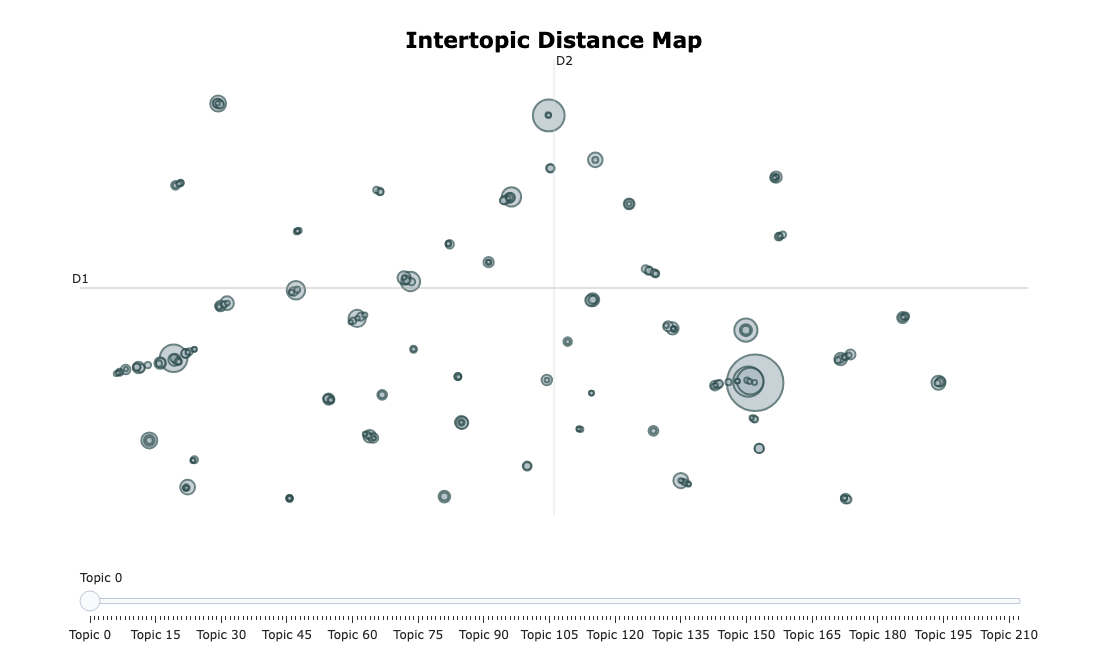

In [12]:

topic_model.visualize_topics()

# Dokumente visualisieren

In [23]:
import plotly.io as pio

# Forcing plotly to render in notebook
pio.renderers.default = "iframe"

In [24]:

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = sentence_model.encode(docs, show_progress_bar=False)

# Train BERTopic
topic_model = BERTopic().fit(docs, embeddings)

# Run the visualization with the original embeddings
topic_model.visualize_documents(docs, embeddings=embeddings)

# Reduce dimensionality of embeddings, this step is optional but much faster to perform iteratively:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings, hide_document_hover=True, width=1000, height=800)


In [15]:
docs = fetch_20newsgroups(subset='all',  remove=('headers', 'footers', 'quotes'))["data"]
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(docs)
hierarchical_topics = topic_model.hierarchical_topics(docs)

2025-07-16 04:24:30,800 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/589 [00:00<?, ?it/s]

2025-07-16 04:25:04,356 - BERTopic - Embedding - Completed ✓
2025-07-16 04:25:04,356 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-16 04:25:06,150 - BERTopic - Dimensionality - Completed ✓
2025-07-16 04:25:06,151 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-07-16 04:25:06,519 - BERTopic - Cluster - Completed ✓
2025-07-16 04:25:06,522 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-16 04:25:07,671 - BERTopic - Representation - Completed ✓
100%|██████████████████████████████████████████████████████████████████████████| 222/222 [00:00<00:00, 638.23it/s]


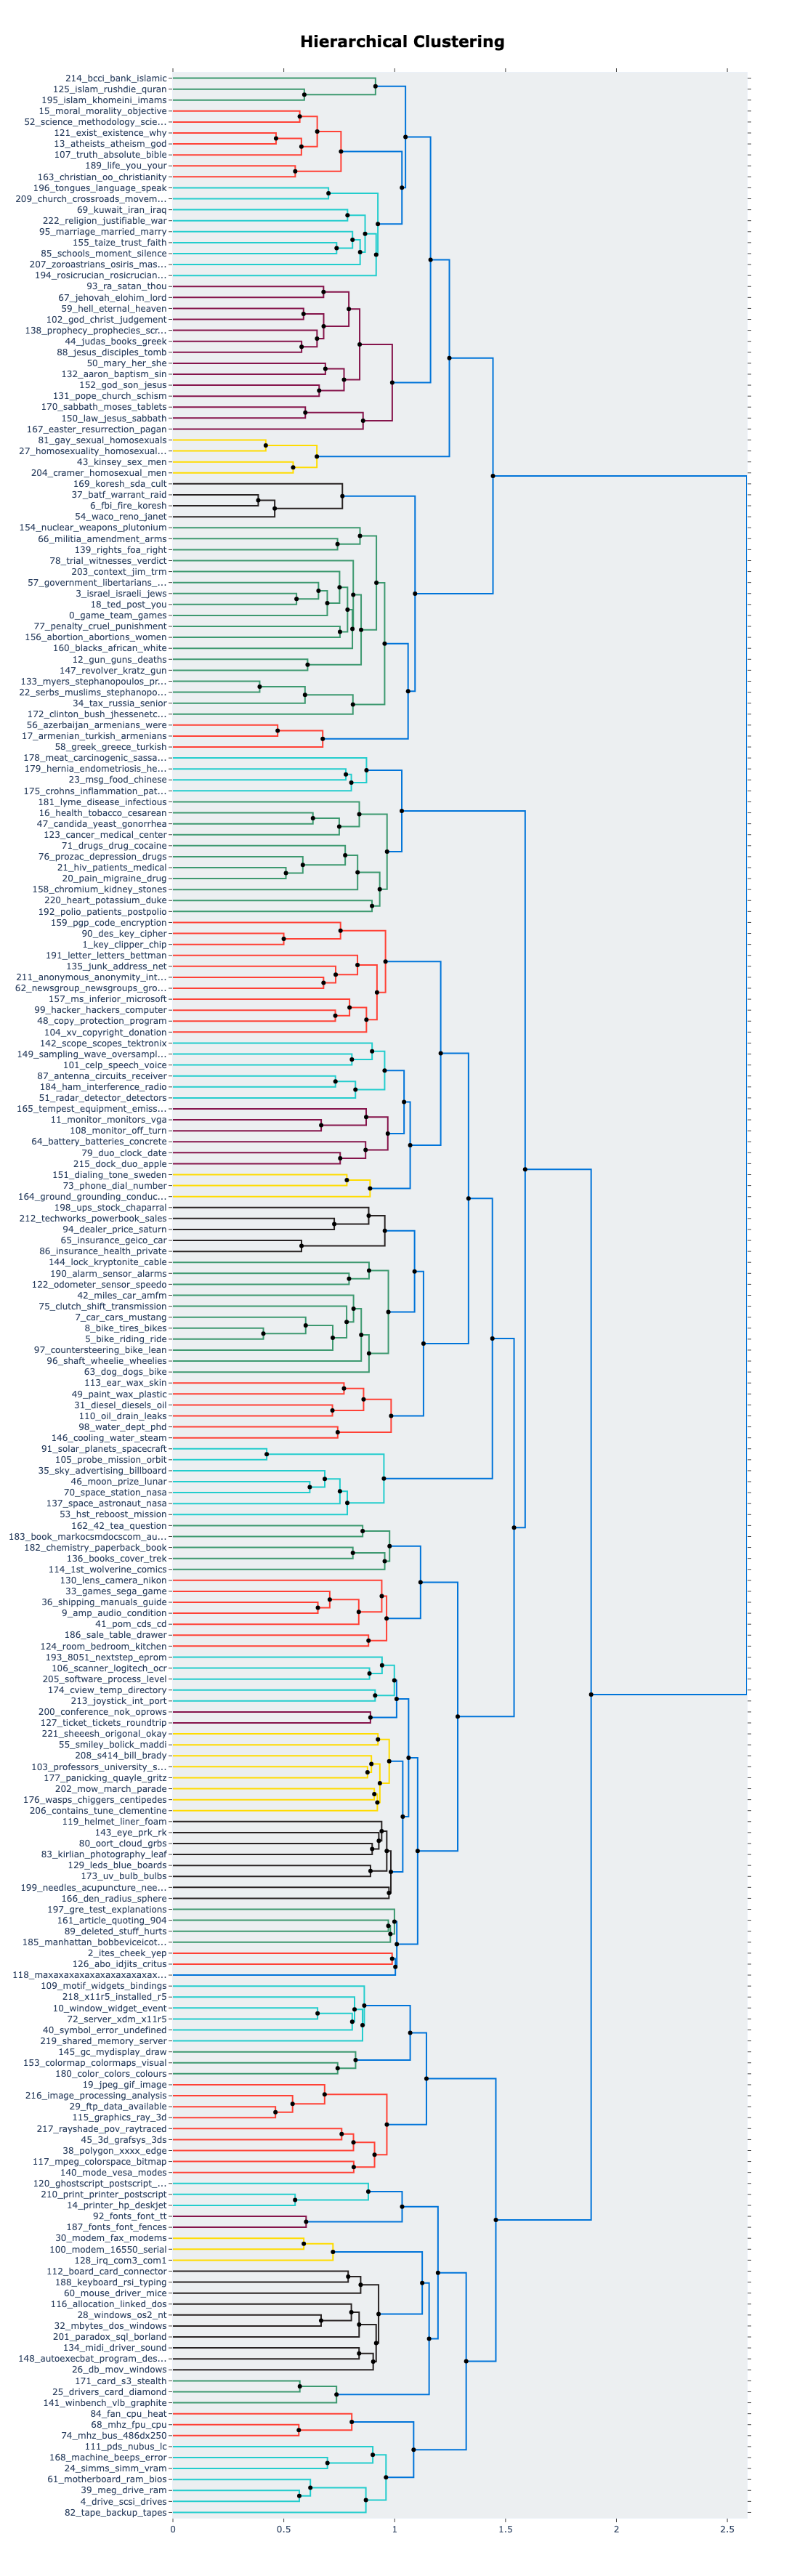

In [16]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [18]:
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = sentence_model.encode(docs, show_progress_bar=False)

# Train BERTopic and extract hierarchical topics
topic_model = BERTopic().fit(docs, embeddings)
hierarchical_topics = topic_model.hierarchical_topics(docs)

topic_model.visualize_hierarchical_documents(docs, hierarchical_topics, embeddings=embeddings)

# Reduce dimensionality of embeddings, this step is optional but much faster to perform iteratively:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)
topic_model.visualize_hierarchical_documents(docs, hierarchical_topics, reduced_embeddings=reduced_embeddings)

100%|██████████████████████████████████████████████████████████████████████████| 218/218 [00:00<00:00, 626.86it/s]
